In [2]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])

0

In [ ]:
# Cell 1 – Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings("ignore")

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

CELL_COL = "CO_DN"
RAW_FILE = "../data/4G raw KPI Cell wise17th_June'26.xlsb"

def short_cell_name(co_dn):
    """
    Input : PLMN-PLMN/MRBTS-803406/LNBTS-803406/LNCEL-41
    Output: LNBTS-803406_LNCEL-41
    """
    parts = str(co_dn).split("/")
    if len(parts) >= 2:
        return f"{parts[-2]}_{parts[-1]}"
    return str(co_dn)

KPI_CONFIG = [
    {
        "col"      : "ERAB Drop Rate_Radio_Nokia_VeMr",
        "label"    : "Drop Rate",
        "threshold": 0.5,
        "direction": "high",
    },
    {
        "col"      : "E2E Call Setup Success Rate_Nokia_VeMr",
        "label"    : "E2E CSSR",
        "threshold": 99.5,
        "direction": "low",
    },
    {
        "col"      : "VoLTE Call Setup Success Rate_Nokia_VeMr",
        "label"    : "VoLTE CSSR",
        "threshold": 99.5,
        "direction": "low",
    },
    {
        "col"      : "Average CQI_Nokia_VeMr",
        "label"    : "CQI",
        "threshold": 7.0,
        "direction": "low",
    },
    {
        "col"      : "Nokia_LTE_DL_User_Throughput_Mbps",
        "label"    : "Avg Thpr",
        "threshold": 3.0,
        "direction": "low",
    },
]

KPI_COLS = [k["col"] for k in KPI_CONFIG]
print("✅ Imports done")
print("   Install if needed: pip install statsmodels")

✅ Imports done
   Install if needed: pip install statsmodels


In [5]:
# Cell 2 – Load all sheets (OPTIMIZED)
import pyxlsb

with pyxlsb.open_workbook(RAW_FILE) as wb:
    sheet_names = wb.sheets

print(f"Found {len(sheet_names)} day-sheets")

# ── Load from cleaned CSV instead of raw xlsb ──
# cleaned_master_data.csv was already built in notebook 02
# Reading one CSV is 10x faster than reading 17 xlsb sheets
CSV_PATH = "../data/cleaned_master_data.csv"

if os.path.exists(CSV_PATH):
    print("Loading from cleaned CSV (fast)...")
    master = pd.read_csv(CSV_PATH)

    if "Short_Cell" not in master.columns:
        master["Short_Cell"] = master[CELL_COL].apply(short_cell_name)

    # Add Day_Index from sheet_names order
    day_order = {day: i for i, day in enumerate(sheet_names)}
    master["Day_Index"] = master["Day"].map(day_order)

    # Keep only needed columns
    keep_cols = ["Short_Cell", CELL_COL, "Day", "Day_Index"] + \
                [c for c in KPI_COLS if c in master.columns]
    master = master[keep_cols].copy()

else:
    print("CSV not found — loading from raw xlsb (slow)...")
    dfs = []
    for i, sheet in enumerate(sheet_names):
        print(f"  {sheet[:35]}")
        df = pd.read_excel(RAW_FILE, sheet_name=sheet, engine="pyxlsb")
        df = df.reset_index(drop=True)
        if df.empty or CELL_COL not in df.columns:
            continue
        df["Short_Cell"] = df[CELL_COL].apply(short_cell_name)
        df["Day"]        = sheet
        df["Day_Index"]  = i
        keep = ["Short_Cell", CELL_COL, "Day", "Day_Index"] + \
               [c for c in KPI_COLS if c in df.columns]
        dfs.append(df[keep].copy())
        del df
    master = pd.concat(dfs, ignore_index=True)

# Convert KPIs to numeric
for col in KPI_COLS:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors="coerce")

print(f"Master shape  : {master.shape}")
print(f"Unique cells  : {master['Short_Cell'].nunique()}")
print(f"Days          : {master['Day_Index'].nunique()}")

def build_ts(kpi_col):
    """
    Build time series matrix.
    Rows    = day index (0 to 16)
    Columns = unique Short_Cell names
    Values  = KPI reading for that cell on that day
    """
    if kpi_col not in master.columns:
        return None
    pivot = master.pivot_table(
        index   = "Day_Index",
        columns = "Short_Cell",
        values  = kpi_col,
        aggfunc = "mean"
    )
    return pivot

print("\n✅ Time series builder ready")
sample = build_ts(KPI_COLS[0])
if sample is not None:
    print(f"Sample TS shape: {sample.shape}  (days × cells)")

Found 17 day-sheets
Loading from cleaned CSV (fast)...
Master shape  : (842125, 9)
Unique cells  : 51359
Days          : 17

✅ Time series builder ready
Sample TS shape: (17, 51359)  (days × cells)


In [6]:
# Cell 3 – Augmented Dickey-Fuller stationarity test
# A time series must be stationary for ARIMA to work correctly
# Stationary = constant mean and variance over time
# ADF test: p-value < 0.05 → stationary

kpi_col   = "ERAB Drop Rate_Radio_Nokia_VeMr"
ts_matrix = build_ts(kpi_col).dropna(axis=1, thresh=10)

adf_results = []
# Test first 20 cells to keep output clean
for cell in ts_matrix.columns[:20]:
    series = ts_matrix[cell].dropna()
    if len(series) < 5:
        continue
    result = adfuller(series)
    adf_results.append({
        "Cell"      : cell,
        "ADF Stat"  : round(result[0], 4),
        "p-value"   : round(result[1], 4),
        "Stationary": "✅ Yes" if result[1] < 0.05 else "❌ No"
    })

adf_df = pd.DataFrame(adf_results)
stationary_pct = (adf_df["Stationary"] == "✅ Yes").mean() * 100

print(f"ADF Stationarity Test — Drop Rate\n")
print(adf_df.to_string(index=False))
print(f"\nStationary cells: {stationary_pct:.1f}%")
print(f"\nNote: Non-stationary series will be differenced (d=1) in ARIMA")

ADF Stationarity Test — Drop Rate

                 Cell  ADF Stat  p-value Stationary
  LNBTS-34313_LNCEL-0   -2.5947   0.0941       ❌ No
  LNBTS-34594_LNCEL-0   -3.6283   0.0052      ✅ Yes
LNBTS-400004_LNCEL-10   -4.0513   0.0012      ✅ Yes
LNBTS-400004_LNCEL-11   -2.0972   0.2456       ❌ No
LNBTS-400004_LNCEL-41   -2.9921   0.0356      ✅ Yes
LNBTS-400004_LNCEL-42   -0.1491   0.9443       ❌ No
LNBTS-400004_LNCEL-43   -6.7532   0.0000      ✅ Yes
LNBTS-400004_LNCEL-44   -3.1173   0.0253      ✅ Yes
LNBTS-400004_LNCEL-45   -2.8773   0.0481      ✅ Yes
LNBTS-400004_LNCEL-46   -2.8337   0.0536       ❌ No
LNBTS-400004_LNCEL-91   -2.8843   0.0472      ✅ Yes
LNBTS-400004_LNCEL-92   -3.2160   0.0191      ✅ Yes
LNBTS-400004_LNCEL-93   -2.4849   0.1192       ❌ No
LNBTS-400655_LNCEL-41    1.9561   0.9986       ❌ No
LNBTS-400655_LNCEL-42   -1.8508   0.3555       ❌ No
LNBTS-400655_LNCEL-43   -3.1682   0.0219      ✅ Yes
LNBTS-400655_LNCEL-44   -1.7573   0.4018       ❌ No
LNBTS-400655_LNCEL-45  -18.56

In [7]:
# Cell 4 – Load chronic cells from notebook 07 output
# We forecast KPIs for these cells since they are already known bad

HEALTH_REPORT = "../outputs/Cell_Health_Score_Report.xlsx"

try:
    chronic_df  = pd.read_excel(HEALTH_REPORT, sheet_name="Chronic Cells")
    chronic_df.columns = [str(c).strip() for c in chronic_df.columns]
    cell_col    = chronic_df.columns[0]
    top_cells   = chronic_df.head(8)[cell_col].tolist()
    print(f"Loaded {len(chronic_df)} chronic cells from nb07")
    print(f"Forecasting for top {len(top_cells)} worst cells:")
    for c in top_cells:
        print(f"  {c}")
except Exception as e:
    print(f"Could not load chronic cells: {e}")
    print("Falling back to worst cells by Drop Rate variance")
    ts_matrix = build_ts(KPI_COLS[0]).dropna(axis=1, thresh=10)
    top_cells  = ts_matrix.std().sort_values(ascending=False).head(8).index.tolist()
    print(f"Using top {len(top_cells)} high-variance cells")

Loaded 740 chronic cells from nb07
Forecasting for top 8 worst cells:
  Cell ID (eNodeB_Cell)
  LNBTS-803213_LNCEL-43
  LNBTS-802870_LNCEL-43
  LNBTS-804916_LNCEL-43
  LNBTS-802685_LNCEL-41
  LNBTS-804916_LNCEL-42
  LNBTS-802288_LNCEL-41
  LNBTS-803213_LNCEL-42


In [8]:
# Cell 5 – Forecast next day KPI for each chronic cell
# Models: Moving Average baseline, Holt-Winters, ARIMA

kpi_col   = "ERAB Drop Rate_Radio_Nokia_VeMr"
threshold = 0.5
ts_matrix = build_ts(kpi_col)

forecast_results = []

for cell in top_cells:
    if ts_matrix is None or cell not in ts_matrix.columns:
        continue

    series = ts_matrix[cell].dropna()
    if len(series) < 7:
        print(f"  Skipping {cell} — not enough data ({len(series)} days)")
        continue

    # Train on first n-2, test on last 2
    train = series.iloc[:-2].values
    test  = series.iloc[-2:].values

    # ── Model 1: Moving Average (baseline) ──
    ma_pred = np.mean(train[-3:])
    ma_preds = np.array([ma_pred, ma_pred])

    # ── Model 2: Holt-Winters ──
    # Handles trend in the data
    try:
        hw = ExponentialSmoothing(
            train,
            trend                = "add",
            initialization_method= "estimated"
        ).fit(optimized=True)
        hw_preds = hw.forecast(2)
        hw_next  = hw.forecast(3)[-1]   # next day beyond test
    except:
        hw_preds = ma_preds
        hw_next  = ma_pred

    # ── Model 3: ARIMA(1,1,1) ──
    # p=1 autoregression, d=1 differencing, q=1 moving average
    try:
        arima    = ARIMA(train, order=(1, 1, 1)).fit()
        ar_preds = arima.forecast(2)
        ar_next  = arima.forecast(3)[-1]
    except:
        ar_preds = ma_preds
        ar_next  = ma_pred

    # ── Evaluate on test set ──
    for name, preds, next_val in [
        ("Moving Average",  ma_preds, ma_pred),
        ("Holt-Winters",    hw_preds, hw_next),
        ("ARIMA(1,1,1)",    ar_preds, ar_next),
    ]:
        mae  = round(mean_absolute_error(test, preds), 4)
        rmse = round(np.sqrt(mean_squared_error(test, preds)), 4)

        forecast_results.append({
            "Cell"             : cell,
            "Model"            : name,
            "MAE"              : mae,
            "RMSE"             : rmse,
            "Next_Day_Forecast": round(next_val, 4),
            "Will_Breach"      : "🚨 Yes" if next_val > threshold else "✅ No",
        })

    print(f"  ✅ {cell}")

forecast_df = pd.DataFrame(forecast_results)
print(f"\n✅ Forecasting complete")
print(f"   {len(top_cells)} cells × 3 models = {len(forecast_df)} results")

  ✅ LNBTS-803213_LNCEL-43
  ✅ LNBTS-802870_LNCEL-43
  ✅ LNBTS-804916_LNCEL-43
  ✅ LNBTS-802685_LNCEL-41
  ✅ LNBTS-804916_LNCEL-42
  ✅ LNBTS-802288_LNCEL-41
  ✅ LNBTS-803213_LNCEL-42

✅ Forecasting complete
   8 cells × 3 models = 21 results


In [9]:
# Cell 6 – Which model performs best across all chronic cells?

print("Model Accuracy Comparison — Drop Rate Forecasting\n")
print(f"{'Model':<20} {'Avg MAE':>10} {'Avg RMSE':>10} {'Best Count':>12}")
print("-" * 55)

model_stats = forecast_df.groupby("Model")[["MAE","RMSE"]].mean().round(4)

# Count how many cells each model won on MAE
best_model_per_cell = (
    forecast_df.groupby(["Cell","Model"])["MAE"]
    .mean()
    .reset_index()
)
best_per_cell = (
    best_model_per_cell.loc[
        best_model_per_cell.groupby("Cell")["MAE"].idxmin()
    ]["Model"]
    .value_counts()
)

for model in model_stats.index:
    avg_mae  = model_stats.loc[model, "MAE"]
    avg_rmse = model_stats.loc[model, "RMSE"]
    best_cnt = best_per_cell.get(model, 0)
    print(f"  {model:<18} {avg_mae:>10.4f} {avg_rmse:>10.4f} {best_cnt:>12}")

best_model = model_stats["MAE"].idxmin()
print(f"\n  ✅ Best model by avg MAE: {best_model}")

Model Accuracy Comparison — Drop Rate Forecasting

Model                   Avg MAE   Avg RMSE   Best Count
-------------------------------------------------------
  ARIMA(1,1,1)           1.7954     1.9758            2
  Holt-Winters           1.9376     2.2956            3
  Moving Average         1.8967     2.0695            2

  ✅ Best model by avg MAE: ARIMA(1,1,1)


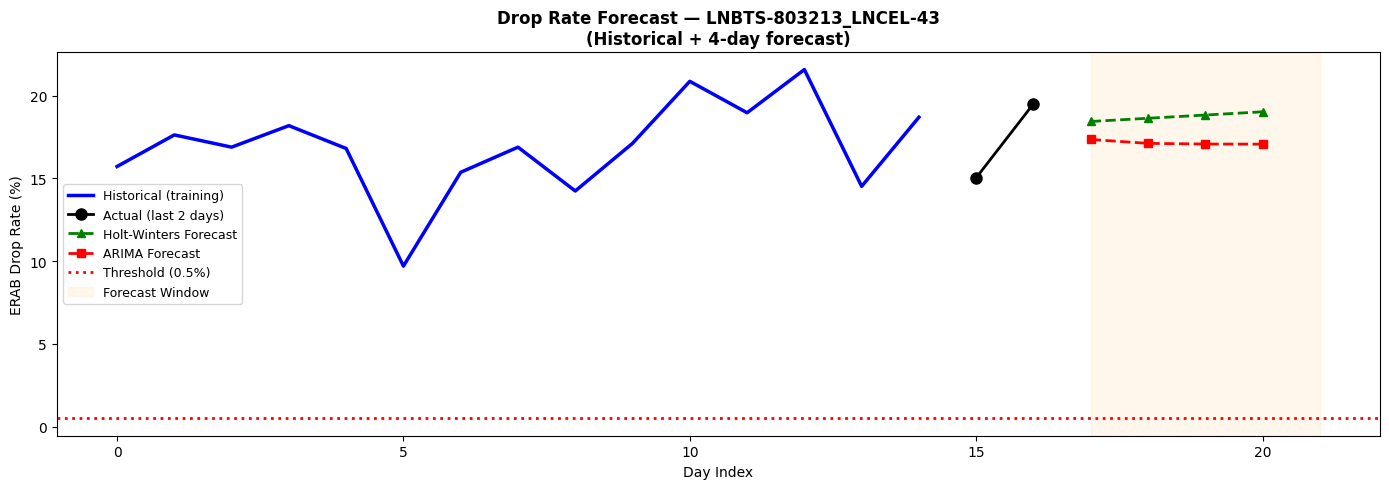

✅ Saved → outputs/ts_forecast_plot.png

Holt-Winters next 4 days: [18.442 18.637 18.832 19.027]
ARIMA        next 4 days: [17.354 17.119 17.078 17.071]


In [10]:
# Cell 7 – Plot historical + forecast for worst chronic cell

kpi_col   = "ERAB Drop Rate_Radio_Nokia_VeMr"
ts_matrix = build_ts(kpi_col)
threshold = 0.5

# Pick worst cell — most days failing
worst_cell = None
for cell in top_cells:
    if cell in ts_matrix.columns:
        worst_cell = cell
        break

if worst_cell:
    series = ts_matrix[worst_cell].dropna()
    train  = series.iloc[:-2].values
    test   = series.iloc[-2:].values

    # Refit models
    try:
        hw       = ExponentialSmoothing(
            train, trend="add",
            initialization_method="estimated"
        ).fit(optimized=True)
        hw_future = hw.forecast(4)
    except:
        hw_future = np.array([train[-1]] * 4)

    try:
        arima     = ARIMA(train, order=(1, 1, 1)).fit()
        ar_future = arima.forecast(4)
    except:
        ar_future = np.array([train[-1]] * 4)

    fig, ax = plt.subplots(figsize=(14, 5))

    x_train  = range(len(train))
    x_test   = range(len(train), len(train) + 2)
    x_future = range(len(train) + 2, len(train) + 6)

    ax.plot(x_train,  train,     "b-",  linewidth=2.5,
            label="Historical (training)")
    ax.plot(x_test,   test,      "ko-", linewidth=2,
            markersize=8, label="Actual (last 2 days)")
    ax.plot(x_future, hw_future, "g--", linewidth=2,
            marker="^", markersize=6, label="Holt-Winters Forecast")
    ax.plot(x_future, ar_future, "r--", linewidth=2,
            marker="s", markersize=6, label="ARIMA Forecast")
    ax.axhline(threshold, color="red", linestyle=":",
               linewidth=2, label=f"Threshold ({threshold}%)")
    ax.axvspan(len(train) + 2, len(train) + 6,
               alpha=0.08, color="orange", label="Forecast Window")

    ax.set_title(
        f"Drop Rate Forecast — {worst_cell}\n"
        f"(Historical + 4-day forecast)",
        fontweight="bold", fontsize=12
    )
    ax.set_xlabel("Day Index")
    ax.set_ylabel("ERAB Drop Rate (%)")
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("../outputs/ts_forecast_plot.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved → outputs/ts_forecast_plot.png")
    print(f"\nHolt-Winters next 4 days: {hw_future.round(3)}")
    print(f"ARIMA        next 4 days: {ar_future.round(3)}")

In [11]:
# Cell 8 – Generate proactive alerts for ALL cells
# Flags cells PREDICTED to breach threshold tomorrow

print("Generating proactive alerts for all cells...\n")
alerts = []

for cfg in KPI_CONFIG:
    kpi_col   = cfg["col"]
    label     = cfg["label"]
    threshold = cfg["threshold"]
    direction = cfg["direction"]

    ts_matrix = build_ts(kpi_col)
    if ts_matrix is None:
        continue

    # Only cells with enough data
    valid_cells = ts_matrix.dropna(axis=1, thresh=5).columns

    for cell in valid_cells:
        series = ts_matrix[cell].dropna()
        if len(series) < 5:
            continue

        train = series.values
        current_val = train[-1]

        # Quick Holt-Winters forecast
        try:
            hw   = ExponentialSmoothing(
                train, trend="add",
                initialization_method="estimated"
            ).fit(optimized=True)
            pred = hw.forecast(1)[0]
        except:
            pred = current_val  # fallback

        # Check breach
        currently_breaching = (
            (direction == "high" and current_val > threshold) or
            (direction == "low"  and current_val < threshold)
        )
        will_breach = (
            (direction == "high" and pred > threshold) or
            (direction == "low"  and pred < threshold)
        )

        if will_breach:
            alerts.append({
                "Cell"              : cell,
                "KPI"               : label,
                "Current_Value"     : round(current_val, 3),
                "Predicted_Tomorrow": round(pred, 3),
                "Threshold"         : threshold,
                "Currently_Failing" : "Yes" if currently_breaching else "No",
                "Alert_Type"        : (
                    "🔴 Worsening"        if currently_breaching else
                    "⚠️  New Breach Expected"
                )
            })

alerts_df = pd.DataFrame(alerts)

if not alerts_df.empty:
    print(f"Total alerts generated  : {len(alerts_df)}")
    print(f"New breaches expected   : "
          f"{len(alerts_df[alerts_df['Alert_Type'].str.contains('New')])}")
    print(f"Worsening cells         : "
          f"{len(alerts_df[alerts_df['Alert_Type'].str.contains('Worsening')])}")
    print(f"\nBreakdown by KPI:")
    print(alerts_df.groupby("KPI")["Cell"].count()
          .sort_values(ascending=False).to_string())

    alerts_df.to_csv("../outputs/proactive_alerts.csv", index=False)
    print(f"\n✅ Saved → outputs/proactive_alerts.csv")
    print(f"\nSample alerts:")
    print(alerts_df.head(10).to_string(index=False))
else:
    print("No alerts generated")

Generating proactive alerts for all cells...



c:\Users\irina\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\irina\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\irina\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\irina\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\irina\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retval

Total alerts generated  : 16121
New breaches expected   : 4624
Worsening cells         : 11497

Breakdown by KPI:
KPI
E2E CSSR      5383
Avg Thpr      3885
Drop Rate     3342
VoLTE CSSR    2076
CQI           1435

✅ Saved → outputs/proactive_alerts.csv

Sample alerts:
                 Cell       KPI  Current_Value  Predicted_Tomorrow  Threshold Currently_Failing              Alert_Type
LNBTS-401003_LNCEL-41 Drop Rate           0.21               0.563        0.5                No ⚠️  New Breach Expected
LNBTS-401003_LNCEL-91 Drop Rate           0.34               0.853        0.5                No ⚠️  New Breach Expected
LNBTS-401003_LNCEL-92 Drop Rate           0.67               0.721        0.5               Yes             🔴 Worsening
LNBTS-401005_LNCEL-91 Drop Rate           0.71               0.695        0.5               Yes             🔴 Worsening
LNBTS-401013_LNCEL-91 Drop Rate           0.47               0.526        0.5                No ⚠️  New Breach Expected
LNBTS-40103

In [12]:
# Cell 9 – Summary

print("=" * 60)
print("TIME SERIES FORECASTING SUMMARY — Vi PJB 4G")
print("=" * 60)

print(f"\nData:")
print(f"  Days monitored  : {len(sheet_names)}")
print(f"  Unique cells    : {master['Short_Cell'].nunique()}")
print(f"  KPIs forecasted : {len(KPI_CONFIG)}")

print(f"\nModels Used:")
print(f"  1. Moving Average  — simple baseline (last 3 days avg)")
print(f"  2. Holt-Winters    — handles trend in KPI data")
print(f"  3. ARIMA(1,1,1)    — autoregression + differencing")

print(f"\nStationarity:")
stationary_count = (adf_df["Stationary"] == "✅ Yes").sum()
print(f"  {stationary_count}/{len(adf_df)} tested cells are stationary")
print(f"  Non-stationary handled via d=1 differencing in ARIMA")

print(f"\nBest Model: {best_model}")
print(f"  Selected by lowest average MAE across {len(top_cells)} chronic cells")

if not alerts_df.empty:
    print(f"\nProactive Alerts:")
    print(f"  Total alerts        : {len(alerts_df)}")
    new_breach = len(alerts_df[alerts_df["Alert_Type"].str.contains("New")])
    worsening  = len(alerts_df[alerts_df["Alert_Type"].str.contains("Worsening")])
    print(f"  New breaches        : {new_breach}")
    print(f"  Worsening cells     : {worsening}")

print(f"\nOutput Files:")
for f in ["ts_forecast_plot.png", "proactive_alerts.csv"]:
    path   = f"../outputs/{f}"
    exists = "✅" if os.path.exists(path) else "❌"
    print(f"  {exists}  {f}")

TIME SERIES FORECASTING SUMMARY — Vi PJB 4G

Data:
  Days monitored  : 17
  Unique cells    : 51359
  KPIs forecasted : 5

Models Used:
  1. Moving Average  — simple baseline (last 3 days avg)
  2. Holt-Winters    — handles trend in KPI data
  3. ARIMA(1,1,1)    — autoregression + differencing

Stationarity:
  12/20 tested cells are stationary
  Non-stationary handled via d=1 differencing in ARIMA

Best Model: ARIMA(1,1,1)
  Selected by lowest average MAE across 8 chronic cells

Proactive Alerts:
  Total alerts        : 16121
  New breaches        : 4624
  Worsening cells     : 11497

Output Files:
  ✅  ts_forecast_plot.png
  ✅  proactive_alerts.csv
